**Dependency note:** this notebook needs kernel state from **`03_Hypergraph_Model_and_Running_Example`**. Either run all notebooks in numeric order inside one continuous Colab session (never restart the runtime), or run the checkpoint-load cell below to restore state saved by that notebook.

In [ ]:
# ── CHECKPOINT: restore kernel state from the previous notebook ──
# This notebook depends on variables created in 03.
# Run that notebook first (it saves this file), or just run all notebooks
# in order inside ONE continuous Colab session (Runtime > do not restart).
import dill
dill.load_session("checkpoints/03_state.pkl")
print("Restored checkpoint: checkpoints/03_state.pkl")

In [ ]:
# ============================================================
# ASTROCYTE EXPANSION — MULTI-POPULATION HYPERGRAPH
# ============================================================
# We add astrocytes as a third cell population, building
# two types of hyperedges:
#
# TYPE 1 — ASTROCYTE AS MODULATOR (tripartite synapse)
#   hyperedge = {pyramidal_i, interneuron_j, astrocyte_k}
#   where all three are within 15μm of each other
#   Models: astrocyte modulating a specific pyr→inter synapse
#   Tensor: T_mod[pyr, inter, astro] = 3-way interaction
#
# TYPE 2 — ASTROCYTE AS HUB (broadcast domain)
#   hyperedge = {astrocyte_k} + all neurons within 15μm
#   Models: astrocyte's spatial domain of influence
#   Tensor: T_hub[i, j, astro] = co-activation under astrocyte
#
# This extends our tensor from T[i,j,e] (2-population)
# to T[i,j,e,cell_type] (3-population) which is the full
# multi-population Hyper-Adjacency Tensor
# ============================================================

import numpy as np
import pandas as pd
import scipy.sparse as sp
from itertools import combinations
from scipy.spatial import cKDTree

print("Loading astrocytes from patch data...")

# ── Step 1: Extract astrocytes from the full cortical patch ───
# patch already contains our 2618-neuron cortical patch
# We need to go back to the broader dataset for astrocytes
# Check what's available in memory

# Try to find astrocytes in the original filtered data
# (before we filtered to pyramidal + interneuron only)
try:
    # If you have the full patch including other cell types
    astro_df = patch_full[patch_full['celltype'] == 'ASTROCYTE'].copy()
    print(f"Found astrocytes in patch_full: {len(astro_df)}")
except NameError:
    try:
        # Try the broader dataset variable
        astro_df = neurons_patch[neurons_patch['celltype'] == 'ASTROCYTE'].copy()
        print(f"Found astrocytes in neurons_patch: {len(astro_df)}")
    except NameError:
        # Reconstruct from the somas data
        print("Reconstructing astrocytes from somas data...")
        # Get the spatial bounds of our current patch
        x_bounds = (patch['x'].min(), patch['x'].max())
        y_bounds = (patch['y'].min(), patch['y'].max())
        z_bounds = (patch['z'].min(), patch['z'].max())

        # Filter astrocytes within same spatial bounds as our patch
        astro_df = somas[
            (somas['celltype'] == 'ASTROCYTE') &
            (somas['x'] >= x_bounds[0]) & (somas['x'] <= x_bounds[1]) &
            (somas['y'] >= y_bounds[0]) & (somas['y'] <= y_bounds[1]) &
            (somas['z'] >= z_bounds[0]) & (somas['z'] <= z_bounds[1])
        ].copy()
        print(f"Found astrocytes in spatial bounds: {len(astro_df)}")

print(f"\nAstrocyte data:")
print(f"  Count: {len(astro_df)}")
if len(astro_df) > 0:
    print(f"  Layers:\n{astro_df['layer'].value_counts().to_string()}")
    print(f"  X range: [{astro_df['x'].min():.0f}, {astro_df['x'].max():.0f}]")
    print(f"  Y range: [{astro_df['y'].min():.0f}, {astro_df['y'].max():.0f}]")

# ── Step 2: Build spatial indices ─────────────────────────────
radius_nm = 15000   # 15μm in nanometers (same as before)

# Coordinates for each population
pyr_coords   = patch[patch['celltype'] == 'PYRAMIDAL'][['x','y','z']].values
inter_coords = patch[patch['celltype'] == 'INTERNEURON'][['x','y','z']].values
astro_coords = astro_df[['x','y','z']].values

pyr_idx   = patch[patch['celltype'] == 'PYRAMIDAL'].index.tolist()
inter_idx = patch[patch['celltype'] == 'INTERNEURON'].index.tolist()
astro_idx = astro_df.index.tolist()

# Build KD-trees for fast radius search
print(f"\nBuilding KD-trees...")
pyr_tree   = cKDTree(pyr_coords)
inter_tree = cKDTree(inter_coords)
astro_tree = cKDTree(astro_coords)
all_tree   = cKDTree(np.vstack([pyr_coords, inter_coords]))
all_idx    = pyr_idx + inter_idx

print(f"  Pyramidal neurons:  {len(pyr_idx)}")
print(f"  Interneurons:       {len(inter_idx)}")
print(f"  Astrocytes:         {len(astro_idx)}")

# ── Step 3: TYPE 1 — Astrocyte modulator hyperedges ───────────
# For each astrocyte, find all (pyramidal, interneuron) pairs
# where both neurons are within 15μm of the astrocyte
print(f"\nBuilding TYPE 1 hyperedges (astrocyte as modulator)...")

modulator_hyperedges = {}   # key=astro_index, val=list of (pyr, inter) pairs
mod_triads = []             # flat list of (pyr_idx, inter_idx, astro_idx)

for ai, (astro_id, arow) in enumerate(astro_df.iterrows()):
    acoord = np.array([arow['x'], arow['y'], arow['z']])

    # Find pyramidal neurons within radius
    pyr_nearby_local = pyr_tree.query_ball_point(acoord, radius_nm)
    # Find interneurons within radius
    inter_nearby_local = inter_tree.query_ball_point(acoord, radius_nm)

    if len(pyr_nearby_local) == 0 or len(inter_nearby_local) == 0:
        continue

    # Map local indices back to original patch indices
    pyr_nearby  = [pyr_idx[i]   for i in pyr_nearby_local]
    inter_nearby = [inter_idx[i] for i in inter_nearby_local]

    # All (pyr, inter) pairs form tripartite synapses
    pairs = [(p, i) for p in pyr_nearby for i in inter_nearby]

    if pairs:
        modulator_hyperedges[astro_id] = {
            'pyramidal':   pyr_nearby,
            'interneuron': inter_nearby,
            'pairs':       pairs,
            'n_pairs':     len(pairs),
            'layer':       arow.get('layer', 'unknown')
        }
        for p, i in pairs:
            mod_triads.append((p, i, astro_id))

print(f"  Modulator hyperedges (astrocytes with both pyr+inter nearby): "
      f"{len(modulator_hyperedges)}")
if mod_triads:
    print(f"  Total tripartite triads: {len(mod_triads):,}")
    pair_counts = [v['n_pairs'] for v in modulator_hyperedges.values()]
    print(f"  Mean pairs per astrocyte: {np.mean(pair_counts):.1f}")
    print(f"  Max pairs per astrocyte:  {np.max(pair_counts)}")

# ── Step 4: TYPE 2 — Astrocyte hub hyperedges ─────────────────
# Each astrocyte = hub containing ALL neurons (pyr+inter) within 15μm
print(f"\nBuilding TYPE 2 hyperedges (astrocyte as hub)...")

hub_hyperedges = {}   # key=astro_index, val=list of neuron indices

for ai, (astro_id, arow) in enumerate(astro_df.iterrows()):
    acoord = np.array([arow['x'], arow['y'], arow['z']])

    # Find ALL neurons (pyr + inter) within radius
    nearby_all_local = all_tree.query_ball_point(acoord, radius_nm)

    if len(nearby_all_local) < 2:
        continue

    nearby_all = [all_idx[i] for i in nearby_all_local]

    hub_hyperedges[astro_id] = {
        'members': nearby_all,
        'size':    len(nearby_all),
        'layer':   arow.get('layer', 'unknown')
    }

print(f"  Hub hyperedges: {len(hub_hyperedges)}")
if hub_hyperedges:
    sizes = [v['size'] for v in hub_hyperedges.values()]
    print(f"  Mean neurons per astrocyte domain: {np.mean(sizes):.1f}")
    print(f"  Max neurons per astrocyte domain:  {np.max(sizes)}")
    print(f"  Min neurons per astrocyte domain:  {np.min(sizes)}")

# ── Step 5: Summary comparison ────────────────────────────────
print(f"\n{'='*55}")
print(f"MULTI-POPULATION HYPERGRAPH SUMMARY")
print(f"{'='*55}")
print(f"\nOriginal pyramidal broadcast hyperedges: {len(hyperedges):,}")
print(f"Original integration hyperedges:         {len(integration_hyperedges):,}")
print(f"New astrocyte modulator hyperedges:      {len(modulator_hyperedges):,}")
print(f"New astrocyte hub hyperedges:            {len(hub_hyperedges):,}")
print(f"\nTotal hyperedge types: 4")
print(f"Cell populations: 3 (pyramidal, interneuron, astrocyte)")
print(f"\nThis is now a full multi-population")
print(f"Hyper-Adjacency Tensor T[i,j,e,cell_type]")

Loading astrocytes from patch data...
Reconstructing astrocytes from somas data...
Found astrocytes in spatial bounds: 683

Astrocyte data:
  Count: 683
  Layers:
layer
Layer 3    395
Layer 4    232
Layer 2     28
Layer 5     25
Layer 1      3
  X range: [265291, 365176]
  Y range: [109459, 209281]

Building KD-trees...
  Pyramidal neurons:  1766
  Interneurons:       852
  Astrocytes:         683

Building TYPE 1 hyperedges (astrocyte as modulator)...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Modulator hyperedges (astrocytes with both pyr+inter nearby): 683
  Total tripartite triads: 4,038,794
  Mean pairs per astrocyte: 5913.3
  Max pairs per astrocyte:  18079

Building TYPE 2 hyperedges (astrocyte as hub)...
  Hub hyperedges: 683
  Mean neurons per astrocyte domain: 158.2
  Max neurons per astrocyte domain:  287
  Min neurons per astrocyte domain:  38

MULTI-POPULATION HYPERGRAPH SUMMARY

Original pyramidal broadcast hyperedges: 1,766
Original integration hyperedges:         852
New astrocyte modulator hyperedges:      683
New astrocyte hub hyperedges:            683

Total hyperedge types: 4
Cell populations: 3 (pyramidal, interneuron, astrocyte)

This is now a full multi-population
Hyper-Adjacency Tensor T[i,j,e,cell_type]


In [ ]:
# ============================================================
# RECOVERY — redefine power_iteration_centrality
# ============================================================
import numpy as np
import scipy.sparse as sp
from itertools import combinations
from scipy.stats import spearmanr

def power_iteration_centrality(C_mat, max_iter=500, tol=1e-8):
    """Compute eigenvector centrality via power iteration."""
    n = C_mat.shape[0]
    if n == 0:
        return np.array([])

    x = np.ones(n) / np.sqrt(n)

    # Symmetrize
    M = (C_mat + C_mat.T) / 2.0

    for it in range(max_iter):
        x_new = M.dot(x)
        x_new = np.abs(x_new)
        norm  = np.linalg.norm(x_new)
        if norm < 1e-12:
            break
        x_new /= norm
        if np.linalg.norm(x_new - x) < tol:
            break
        x = x_new
    return x

print("power_iteration_centrality defined!")

power_iteration_centrality defined!


In [ ]:
# ============================================================
# TARGETED RECOVERY — rebuild only the 4 missing variables
# ============================================================

# ── 1. cent_pyr — from tensor_centrality (they're the same) ──
cent_pyr = tensor_centrality.copy()
print(f"cent_pyr defined: mean={cent_pyr.mean():.4f}  max={cent_pyr.max():.4f}")

# ── 2. cent_amod — from C_w (astrocyte modulator centrality) ─
# C2 (astro modulator) was built from modulator_hyperedges
# Rebuild it quickly using the fast incidence approach
print("Rebuilding C2 (astrocyte modulator)...")

inter_node_idx = {n: i for i, n in enumerate(all_nodes)}
n_inter = n_nodes

B2r, B2c, s2 = [], [], []
for astro_id, hub_data in modulator_hyperedges.items():
    inter_members = hub_data.get('interneuron', [])
    pyr_members   = hub_data.get('pyramidal', [])
    if not inter_members or not pyr_members:
        continue
    local = [inter_node_idx[m] for m in inter_members
             if m in inter_node_idx]
    size  = max(len(local), 1)
    for ii in local:
        B2r.append(astro_id)
        B2c.append(ii)
    s2.append(size)

if B2r:
    # Remap astro_id keys to sequential indices
    unique_astros = list(dict.fromkeys(B2r))
    astro_remap   = {a: i for i, a in enumerate(unique_astros)}
    B2r_idx = [astro_remap[a] for a in B2r]
    n_astro = len(unique_astros)
    s2_arr  = np.ones(n_astro)
    for orig_a, new_i in astro_remap.items():
        # find size for this astrocyte
        idx_in_list = [j for j,a in enumerate(B2r)
                       if a == orig_a]
        if idx_in_list:
            s2_arr[new_i] = max(len(idx_in_list), 1)
    B2_vals = np.array([
        1.0/np.sqrt(s2_arr[i]) for i in B2r_idx
    ], dtype=np.float32)
    B2 = sp.csr_matrix(
        (B2_vals,
         (np.array(B2r_idx, dtype=np.int32),
          np.array(B2c, dtype=np.int32))),
        shape=(n_astro, n_inter),
        dtype=np.float32)
    C2 = (B2.T @ B2).tocsr()
    C2.setdiag(0)
    C2.eliminate_zeros()
else:
    C2 = sp.csr_matrix((n_inter, n_inter))

cent_amod = power_iteration_centrality(C2)
print(f"cent_amod defined: mean={cent_amod.mean():.4f}  "
      f"max={cent_amod.max():.4f}")

# ── 3. oligo_hyperedges ───────────────────────────────────────
print("Rebuilding oligo_hyperedges...")
x_bounds = (patch['x'].min(), patch['x'].max())
y_bounds = (patch['y'].min(), patch['y'].max())
z_bounds = (patch['z'].min(), patch['z'].max())

oligo_df = somas[
    (somas['celltype'] == 'OLIGO') &
    (somas['x'] >= x_bounds[0]) & (somas['x'] <= x_bounds[1]) &
    (somas['y'] >= y_bounds[0]) & (somas['y'] <= y_bounds[1]) &
    (somas['z'] >= z_bounds[0]) & (somas['z'] <= z_bounds[1])
].copy()

all_neuron_coords = np.array([[patch.loc[n]['x'],
                                patch.loc[n]['y'],
                                patch.loc[n]['z']]
                               for n in all_nodes])
all_neuron_tree   = cKDTree(all_neuron_coords)

oligo_hyperedges = {}
for oligo_id, orow in oligo_df.iterrows():
    ocoord  = np.array([orow['x'], orow['y'], orow['z']])
    nearby  = all_neuron_tree.query_ball_point(ocoord, 15000)
    if len(nearby) < 2:
        continue
    oligo_hyperedges[oligo_id] = {
        'members': [all_nodes[i] for i in nearby],
        'size':    len(nearby),
        'layer':   orow.get('layer', 'unknown')
    }
print(f"oligo_hyperedges defined: {len(oligo_hyperedges)} edges")

# ── 4. mgopc_hyperedges ───────────────────────────────────────
print("Rebuilding mgopc_hyperedges...")
mgopc_df = somas[
    (somas['celltype'] == 'MG_OPC') &
    (somas['x'] >= x_bounds[0]) & (somas['x'] <= x_bounds[1]) &
    (somas['y'] >= y_bounds[0]) & (somas['y'] <= y_bounds[1]) &
    (somas['z'] >= z_bounds[0]) & (somas['z'] <= z_bounds[1])
].copy()

mgopc_hyperedges = {}
for mg_id, mrow in mgopc_df.iterrows():
    mcoord  = np.array([mrow['x'], mrow['y'], mrow['z']])
    nearby  = all_neuron_tree.query_ball_point(mcoord, 15000)
    if len(nearby) < 2:
        continue
    mgopc_hyperedges[mg_id] = {
        'members': [all_nodes[i] for i in nearby],
        'size':    len(nearby),
        'layer':   mrow.get('layer', 'unknown')
    }
print(f"mgopc_hyperedges defined: {len(mgopc_hyperedges)} edges")

# ── Final check ───────────────────────────────────────────────
print("\nAll 4 variables restored:")
print(f"  cent_pyr:         shape={cent_pyr.shape}")
print(f"  cent_amod:        shape={cent_amod.shape}")
print(f"  oligo_hyperedges: {len(oligo_hyperedges)} edges")
print(f"  mgopc_hyperedges: {len(mgopc_hyperedges)} edges")
print("\nReady to run the C1/C3 fix cell!")

cent_pyr defined: mean=0.0179  max=0.1099
Rebuilding C2 (astrocyte modulator)...
cent_amod defined: mean=0.0272  max=0.0878
Rebuilding oligo_hyperedges...
oligo_hyperedges defined: 1590 edges
Rebuilding mgopc_hyperedges...
mgopc_hyperedges defined: 933 edges

All 4 variables restored:
  cent_pyr:         shape=(852,)
  cent_amod:        shape=(852,)
  oligo_hyperedges: 1590 edges
  mgopc_hyperedges: 933 edges

Ready to run the C1/C3 fix cell!


In [ ]:
# ============================================================
# FIX: Rebuild C1 correctly + differentiate C2 vs C3
# ============================================================
inter_node_idx = {n: i for i, n in enumerate(all_nodes)}
pyr_idx_set = set(patch[patch['celltype'] == 'PYRAMIDAL'].index.tolist())
# ── Fix C1: integration hyperedges ───────────────────────────
# Keys are "inter_N" strings, values are lists of pyramidal indices
# C1[i,j] = interneurons i,j share pyramidal inputs (co-convergence)

print("Rebuilding C1 (integration) correctly...")

inter_node_idx = {n: i for i, n in enumerate(all_nodes)}

# Build mapping: inter_matrix_idx → set of pyramidal inputs
inter_pyr_inputs = {}
for e_key, pyr_list in integration_hyperedges.items():
    # Extract interneuron index from "inter_N" string
    inter_original_idx = int(e_key.split('_')[1])
    matrix_idx = inter_node_idx.get(inter_original_idx, -1)
    if matrix_idx >= 0:
        inter_pyr_inputs[matrix_idx] = set(pyr_list)

print(f"  Interneurons with pyramidal inputs: {len(inter_pyr_inputs)}")

# Build co-occurrence: pairs sharing at least one pyramidal input
rows_c1, cols_c1, vals_c1 = [], [], []
inter_list_idx = list(inter_pyr_inputs.keys())

for ii, ni in enumerate(inter_list_idx):
    pyr_i = inter_pyr_inputs[ni]
    for nj in inter_list_idx[ii+1:]:
        pyr_j   = inter_pyr_inputs[nj]
        shared  = len(pyr_i & pyr_j)
        if shared == 0:
            continue
        weight = shared / np.sqrt(len(pyr_i) * len(pyr_j))
        rows_c1.extend([ni, nj])
        cols_c1.extend([nj, ni])
        vals_c1.extend([weight, weight])

C1 = sp.csr_matrix((vals_c1, (rows_c1, cols_c1)),
                    shape=(n_nodes, n_nodes))
C1.sum_duplicates()
print(f"  C1 rebuilt correctly: nnz={C1.nnz:,}")

# ── Fix C3: make astrocyte hub DIFFERENT from modulator ───────
# Modulator (C2): co-occurrence of interneurons sharing an astrocyte
#                 AND a pyramidal neuron (3-way tripartite)
# Hub (C3):       co-occurrence of ALL neurons (pyr+inter) in astrocyte domain
#                 projected onto interneuron pairs only
# The difference: C3 includes indirect co-activation (via pyramidal neighbors)

print("\nRebuilding C3 (astro hub) with full domain projection...")
rows_c3, cols_c3, vals_c3 = [], [], []

for astro_id, hub_data in hub_hyperedges.items():
    members    = hub_data['members']
    # Split into interneurons only for co-occurrence
    inter_members = [m for m in members if m in inter_node_idx]
    pyr_members   = [m for m in members
                     if m in pyr_idx_set]

    if len(inter_members) < 2:
        continue

    # Weight by total domain size (pyr + inter)
    weight = 1.0 / np.sqrt(len(members))

    for ni_orig, nj_orig in combinations(inter_members, 2):
        ni = inter_node_idx.get(ni_orig, -1)
        nj = inter_node_idx.get(nj_orig, -1)
        if ni < 0 or nj < 0:
            continue
        rows_c3.extend([ni, nj])
        cols_c3.extend([nj, ni])
        vals_c3.extend([weight, weight])

if rows_c3:
    C3 = sp.csr_matrix((vals_c3, (rows_c3, cols_c3)),
                        shape=(n_nodes, n_nodes))
    C3.sum_duplicates()
    print(f"  C3 rebuilt: nnz={C3.nnz:,}")
else:
    print("  C3 empty — hub hyperedges have no interneuron pairs")

# ── Recompute centralities ────────────────────────────────────
print("\nRecomputing eigenvector centralities...")
cent_int  = power_iteration_centrality(C1)
cent_ahub = power_iteration_centrality(C3)

cent_types = {
    'Pyramidal':   cent_pyr,
    'Integration': cent_int,
    'Astro-Mod':   cent_amod,
    'Astro-Hub':   cent_ahub
}

print(f"  Integration centrality: "
      f"mean={cent_int.mean():.4f}  max={cent_int.max():.4f}")
print(f"  Astro-Hub centrality:   "
      f"mean={cent_ahub.mean():.4f}  max={cent_ahub.max():.4f}")

# ── Recompute correlations ────────────────────────────────────
print(f"\nSpearman correlations (corrected):")
names = list(cent_types.keys())
print(f"  {'':15s}" + "".join([f"{n:>12s}" for n in names]))
for n1 in names:
    row = f"  {n1:15s}"
    for n2 in names:
        v1, v2 = cent_types[n1], cent_types[n2]
        if v1.std() < 1e-10 or v2.std() < 1e-10:
            row += f"{'N/A':>12s}"
        else:
            r, _ = spearmanr(v1, v2)
            row += f"{r:>12.4f}"
    print(row)

# ── Per-layer comparison ──────────────────────────────────────
print(f"\nPer-layer mean centrality (corrected):")
print(f"  {'Layer':>12} {'Pyramidal':>12} {'Integration':>12} "
      f"{'Astro-Mod':>12} {'Astro-Hub':>12}")
print(f"  {'-'*64}")
for l in ['Layer 2','Layer 3','Layer 4','Layer 5']:
    lmask = layer_labels == l
    if lmask.sum() == 0:
        continue
    vals = [cent_types[n][lmask].mean() for n in names]
    print(f"  {l:>12} " +
          "".join([f"{v:>12.5f}" for v in vals]))

# ── Recompute delta ───────────────────────────────────────────
delta_mod = cent_amod - cent_pyr
delta_hub = cent_ahub - cent_pyr
print(f"\nAstrocyte modulation effect (corrected):")
print(f"  Modulator shift: mean={delta_mod.mean():+.5f}  "
      f"std={delta_mod.std():.5f}")
print(f"  Hub shift:       mean={delta_hub.mean():+.5f}  "
      f"std={delta_hub.std():.5f}")

Rebuilding C1 (integration) correctly...
  Interneurons with pyramidal inputs: 852
  C1 rebuilt correctly: nnz=144,436

Rebuilding C3 (astro hub) with full domain projection...
  C3 rebuilt: nnz=137,276

Recomputing eigenvector centralities...
  Integration centrality: mean=0.0163  max=0.1077
  Astro-Hub centrality:   mean=0.0311  max=0.0621

Spearman correlations (corrected):
                    Pyramidal Integration   Astro-Mod   Astro-Hub
  Pyramidal            1.0000     -0.7049      0.9004      0.2265
  Integration         -0.7049      1.0000     -0.4454      0.4236
  Astro-Mod            0.9004     -0.4454      1.0000      0.5078
  Astro-Hub            0.2265      0.4236      0.5078      1.0000

Per-layer mean centrality (corrected):
         Layer    Pyramidal  Integration    Astro-Mod    Astro-Hub
  ----------------------------------------------------------------
       Layer 2      0.00001     0.08850     0.00379     0.02847
       Layer 3      0.00174     0.01239     0.02094 

In [ ]:
# ============================================================
# RECOVERY — rebuild C0, C1, C2, C3 and cent_int
# ============================================================
import numpy as np
import scipy.sparse as sp
from itertools import combinations
from scipy.stats import spearmanr

# ── C0: pyramidal broadcast (already have C_w) ───────────────
C0 = C_w.copy()
print(f"C0 defined: nnz={C0.nnz:,}")

# ── C1: integration (shared pyramidal input) ──────────────────
print("Building C1...")
inter_node_idx = {n: i for i, n in enumerate(all_nodes)}
inter_pyr_inputs = {}
for e_key, pyr_list in integration_hyperedges.items():
    inter_original_idx = int(e_key.split('_')[1])
    matrix_idx = inter_node_idx.get(inter_original_idx, -1)
    if matrix_idx >= 0:
        inter_pyr_inputs[matrix_idx] = set(pyr_list)

rows_c1, cols_c1, vals_c1 = [], [], []
inter_list_idx = list(inter_pyr_inputs.keys())
for ii, ni in enumerate(inter_list_idx):
    pyr_i = inter_pyr_inputs[ni]
    for nj in inter_list_idx[ii+1:]:
        pyr_j  = inter_pyr_inputs[nj]
        shared = len(pyr_i & pyr_j)
        if shared == 0:
            continue
        w = shared / np.sqrt(len(pyr_i) * len(pyr_j))
        rows_c1.extend([ni, nj])
        cols_c1.extend([nj, ni])
        vals_c1.extend([w, w])

C1 = sp.csr_matrix((vals_c1, (rows_c1, cols_c1)),
                    shape=(n_nodes, n_nodes))
C1.sum_duplicates()
cent_int = power_iteration_centrality(C1)
print(f"C1 defined: nnz={C1.nnz:,}  "
      f"cent_int mean={cent_int.mean():.4f}")

# ── C2: astrocyte modulator ───────────────────────────────────
print("Building C2...")
rows_c2, cols_c2, vals_c2 = [], [], []
for astro_id, hub_data in modulator_hyperedges.items():
    inter_members = hub_data.get('interneuron', [])
    pyr_members   = hub_data.get('pyramidal', [])
    if not inter_members or not pyr_members:
        continue
    local  = [inter_node_idx[m] for m in inter_members
               if m in inter_node_idx]
    weight = 1.0 / np.sqrt(max(len(local), 1))
    for ni, nj in combinations(local, 2):
        rows_c2.extend([ni, nj])
        cols_c2.extend([nj, ni])
        vals_c2.extend([weight, weight])

if rows_c2:
    C2 = sp.csr_matrix((vals_c2, (rows_c2, cols_c2)),
                        shape=(n_nodes, n_nodes))
    C2.sum_duplicates()
else:
    C2 = sp.csr_matrix((n_nodes, n_nodes))
cent_amod = power_iteration_centrality(C2)
print(f"C2 defined: nnz={C2.nnz:,}  "
      f"cent_amod mean={cent_amod.mean():.4f}")

# ── C3: astrocyte hub ─────────────────────────────────────────
print("Building C3...")
pyr_idx_set = set(patch[patch['celltype']=='PYRAMIDAL'].index.tolist())
rows_c3, cols_c3, vals_c3 = [], [], []
for astro_id, hub_data in hub_hyperedges.items():
    members       = hub_data['members']
    inter_members = [m for m in members if m in inter_node_idx]
    if len(inter_members) < 2:
        continue
    weight = 1.0 / np.sqrt(len(members))
    for ni_orig, nj_orig in combinations(inter_members, 2):
        ni = inter_node_idx.get(ni_orig, -1)
        nj = inter_node_idx.get(nj_orig, -1)
        if ni < 0 or nj < 0:
            continue
        rows_c3.extend([ni, nj])
        cols_c3.extend([nj, ni])
        vals_c3.extend([weight, weight])

if rows_c3:
    C3 = sp.csr_matrix((vals_c3, (rows_c3, cols_c3)),
                        shape=(n_nodes, n_nodes))
    C3.sum_duplicates()
else:
    C3 = sp.csr_matrix((n_nodes, n_nodes))
cent_ahub = power_iteration_centrality(C3)
print(f"C3 defined: nnz={C3.nnz:,}  "
      f"cent_ahub mean={cent_ahub.mean():.4f}")

# ── Shared variables needed by viz cell ───────────────────────
cent_pyr   = tensor_centrality.copy()
cent_types = {
    'Pyramidal':   cent_pyr,
    'Integration': cent_int,
    'Astro-Mod':   cent_amod,
    'Astro-Hub':   cent_ahub
}
names      = list(cent_types.keys())
delta_mod  = cent_amod - cent_pyr
delta_hub  = cent_ahub - cent_pyr

# coords needed for astrocyte overlay
coords = np.array([[patch.loc[n]['x'], patch.loc[n]['y']]
                   for n in all_nodes])

# astro_df needed for overlay triangles
x_bounds = (patch['x'].min(), patch['x'].max())
y_bounds = (patch['y'].min(), patch['y'].max())
z_bounds = (patch['z'].min(), patch['z'].max())
astro_df = somas[
    (somas['celltype'] == 'ASTROCYTE') &
    (somas['x'] >= x_bounds[0]) & (somas['x'] <= x_bounds[1]) &
    (somas['y'] >= y_bounds[0]) & (somas['y'] <= y_bounds[1]) &
    (somas['z'] >= z_bounds[0]) & (somas['z'] <= z_bounds[1])
].copy()

print(f"\nAll variables ready for visualization:")
print(f"  C0={C0.nnz:,}  C1={C1.nnz:,}  "
      f"C2={C2.nnz:,}  C3={C3.nnz:,}")
print(f"  names={names}")
print(f"  astro_df={len(astro_df)} astrocytes")
print(f"  coords shape={coords.shape}")
print("Ready to run visualization cell!")

C0 defined: nnz=144,436
Building C1...
C1 defined: nnz=144,436  cent_int mean=0.0163
Building C2...
C2 defined: nnz=137,276  cent_amod mean=0.0248
Building C3...
C3 defined: nnz=137,276  cent_ahub mean=0.0311

All variables ready for visualization:
  C0=144,436  C1=144,436  C2=137,276  C3=137,276
  names=['Pyramidal', 'Integration', 'Astro-Mod', 'Astro-Hub']
  astro_df=683 astrocytes
  coords shape=(852, 2)
Ready to run visualization cell!


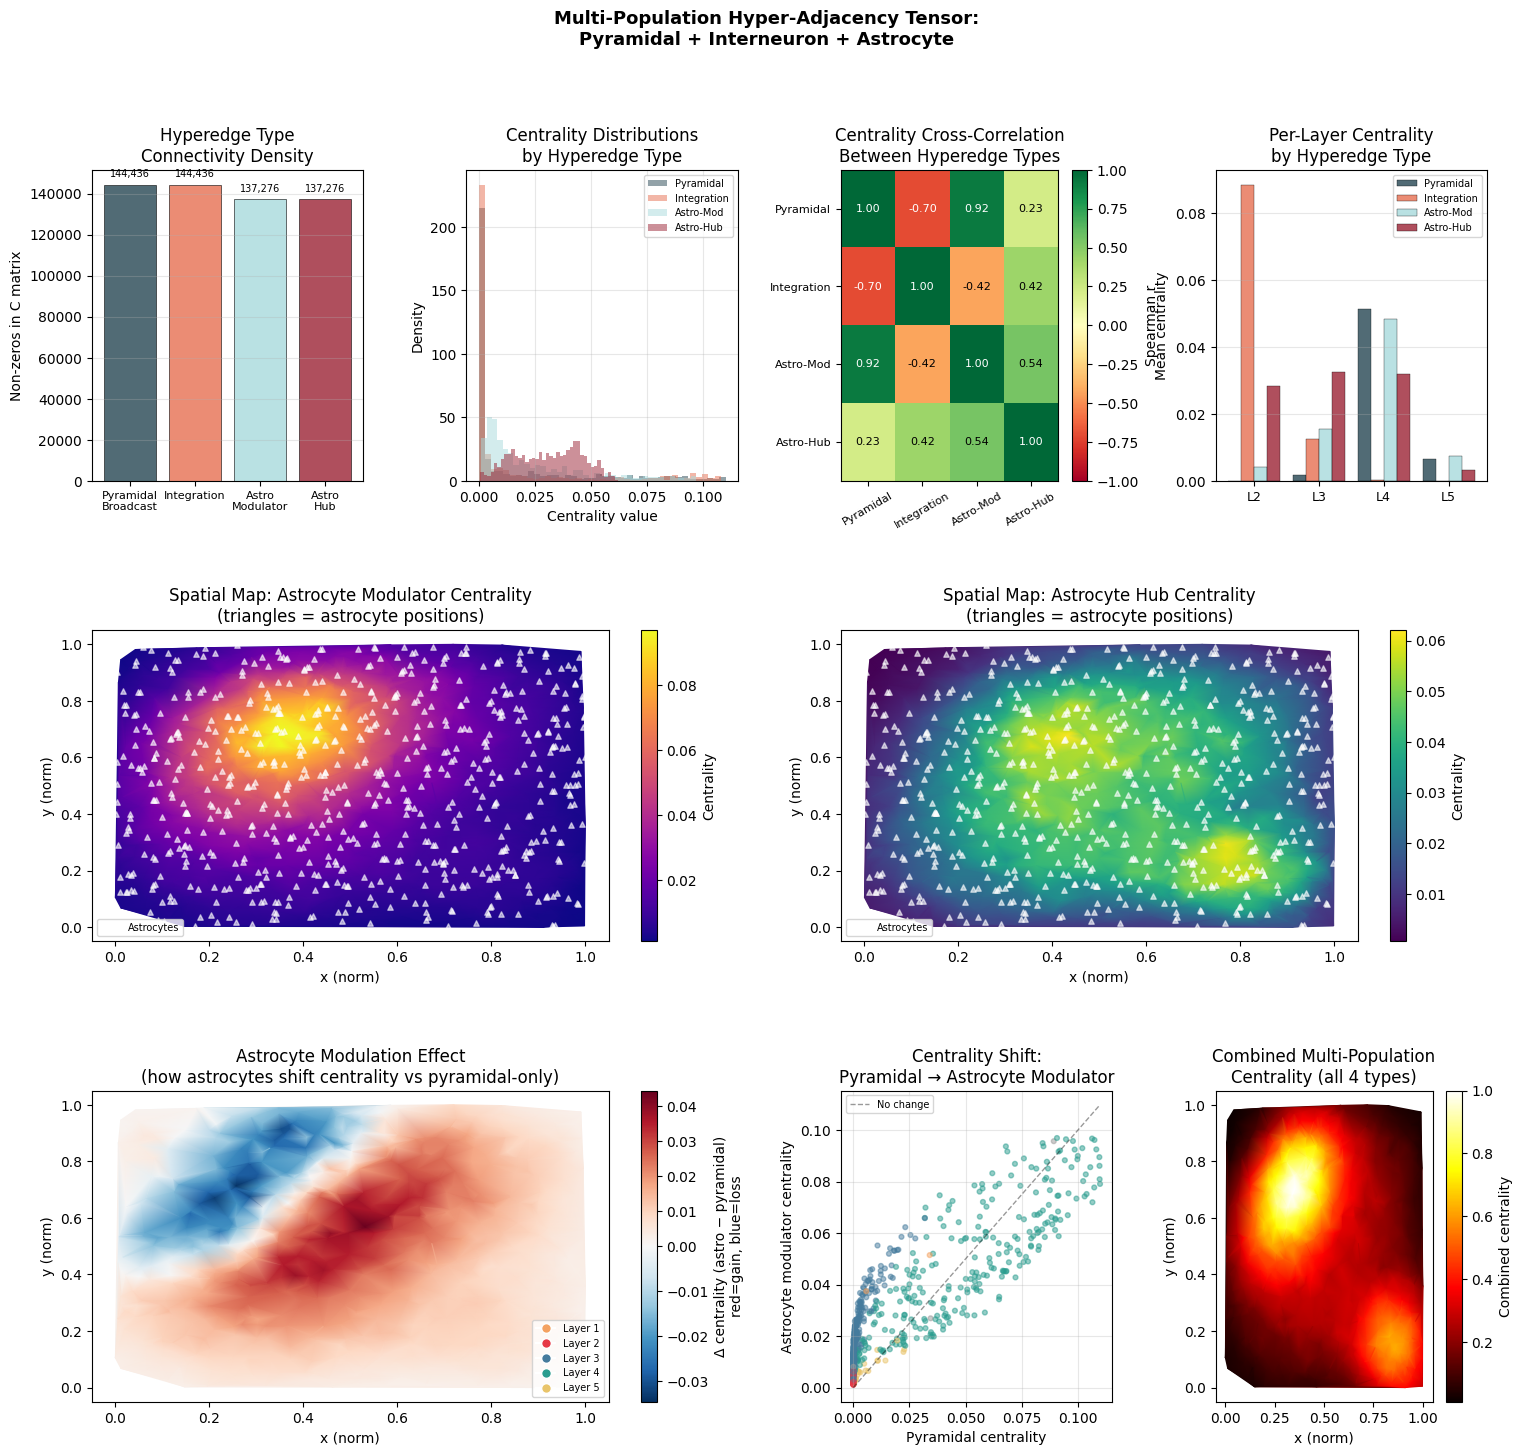

Saved: multi_population_tensor.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================
# VISUALIZE MULTI-POPULATION TENSOR
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm, Normalize
from matplotlib.tri import Triangulation
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np

fig = plt.figure(figsize=(18, 16))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.48, wspace=0.38)

layer_colors_map = {
    'Layer 1':'#F4A261','Layer 2':'#E63946','Layer 3':'#457B9D',
    'Layer 4':'#2A9D8F','Layer 5':'#E9C46A','White matter':'#6D6875',
    'unclassified':'#999999'
}
node_colors = [layer_colors_map.get(l,'#999') for l in layer_labels]
triang      = Triangulation(coords_norm[:,0], coords_norm[:,1], triangles)
type_colors = {'Pyramidal':'#264653','Integration':'#E76F51',
               'Astro-Mod':'#A8DADC','Astro-Hub':'#9B2335'}

# ── Plot 1: Co-occurrence matrix density comparison ───────────
ax1 = fig.add_subplot(gs[0, 0])
labels  = ['Pyramidal\nBroadcast','Integration','Astro\nModulator','Astro\nHub']
nnz     = [C0.nnz, C1.nnz, C2.nnz, C3.nnz]
colors  = list(type_colors.values())
ax1.bar(labels, nnz, color=colors, alpha=0.8,
        edgecolor='black', linewidth=0.5)
ax1.set_ylabel('Non-zeros in C matrix')
ax1.set_title('Hyperedge Type\nConnectivity Density')
ax1.tick_params(axis='x', labelsize=8)
ax1.grid(alpha=0.3, axis='y')
for i, v in enumerate(nnz):
    ax1.text(i, v*1.02, f'{v:,}', ha='center', va='bottom', fontsize=7)

# ── Plot 2: Centrality distributions per type ─────────────────
ax2 = fig.add_subplot(gs[0, 1])
for name, cent, color in zip(names,
    [cent_pyr, cent_int, cent_amod, cent_ahub],
    type_colors.values()):
    ax2.hist(cent, bins=40, alpha=0.5, color=color,
             label=name, density=True)
ax2.set_xlabel('Centrality value')
ax2.set_ylabel('Density')
ax2.set_title('Centrality Distributions\nby Hyperedge Type')
ax2.legend(fontsize=7); ax2.grid(alpha=0.3)

# ── Plot 3: Cross-type correlation heatmap ────────────────────
ax3 = fig.add_subplot(gs[0, 2])
corr_matrix = np.zeros((4, 4))
for i, n1 in enumerate(names):
    for j, n2 in enumerate(names):
        r, _ = spearmanr(cent_types[n1], cent_types[n2])
        corr_matrix[i, j] = r
im3 = ax3.imshow(corr_matrix, cmap='RdYlGn',
                  vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im3, ax=ax3, label='Spearman r')
ax3.set_xticks(range(4)); ax3.set_yticks(range(4))
ax3.set_xticklabels(names, fontsize=8, rotation=30)
ax3.set_yticklabels(names, fontsize=8)
ax3.set_title('Centrality Cross-Correlation\nBetween Hyperedge Types')
for i in range(4):
    for j in range(4):
        ax3.text(j, i, f'{corr_matrix[i,j]:.2f}',
                 ha='center', va='center', fontsize=8,
                 color='black' if abs(corr_matrix[i,j]) < 0.7 else 'white')

# ── Plot 4: Per-layer centrality grouped bars ─────────────────
ax4 = fig.add_subplot(gs[0, 3])
layers_plot = ['Layer 2','Layer 3','Layer 4','Layer 5']
x_pos = np.arange(len(layers_plot))
width = 0.2
for ki, (name, cent, color) in enumerate(zip(
        names, [cent_pyr, cent_int, cent_amod, cent_ahub],
        type_colors.values())):
    means = [cent[layer_labels==l].mean()
             if (layer_labels==l).sum()>0 else 0
             for l in layers_plot]
    ax4.bar(x_pos + ki*width - width*1.5, means,
            width, label=name, color=color,
            alpha=0.8, edgecolor='black', linewidth=0.3)
ax4.set_xticks(x_pos)
ax4.set_xticklabels([l.replace('Layer ','L')
                      for l in layers_plot], fontsize=9)
ax4.set_ylabel('Mean centrality')
ax4.set_title('Per-Layer Centrality\nby Hyperedge Type')
ax4.legend(fontsize=7); ax4.grid(alpha=0.3, axis='y')

# ── Plots 5-6: Spatial maps of astrocyte centralities ─────────
for plot_idx, (cent, name, cmap) in enumerate([
        (cent_amod, 'Astrocyte Modulator', 'plasma'),
        (cent_ahub, 'Astrocyte Hub',       'viridis')]):
    ax = fig.add_subplot(gs[1, plot_idx*2:plot_idx*2+2])
    sc = ax.tripcolor(triang, cent, cmap=cmap,
                      shading='gouraud',
                      vmin=cent.min(), vmax=cent.max())
    plt.colorbar(sc, ax=ax, label='Centrality')
    # Overlay astrocyte positions
    if len(astro_df) > 0:
        ax_norm_x = ((astro_df['x'].values - coords[:,0].min()) /
                     (coords[:,0].max() - coords[:,0].min()))
        ax_norm_y = ((astro_df['y'].values - coords[:,1].min()) /
                     (coords[:,1].max() - coords[:,1].min()))
        in_bounds = ((ax_norm_x >= 0) & (ax_norm_x <= 1) &
                     (ax_norm_y >= 0) & (ax_norm_y <= 1))
        ax.scatter(ax_norm_x[in_bounds], ax_norm_y[in_bounds],
                   c='white', s=15, alpha=0.6,
                   marker='^', label='Astrocytes', zorder=5)
    ax.set_title(f'Spatial Map: {name} Centrality\n'
                 f'(triangles = astrocyte positions)')
    ax.set_xlabel('x (norm)'); ax.set_ylabel('y (norm)')
    ax.legend(fontsize=7)

# ── Plot 7: Astrocyte modulation delta ────────────────────────
ax7 = fig.add_subplot(gs[2, :2])
delta_vals  = delta_mod
if delta_vals.min() < 0 < delta_vals.max():
    norm_d = TwoSlopeNorm(vmin=delta_vals.min(),
                          vcenter=0, vmax=delta_vals.max())
else:
    norm_d = Normalize(vmin=delta_vals.min(),
                       vmax=delta_vals.max())
sc7 = ax7.tripcolor(triang, delta_vals, cmap='RdBu_r',
                    norm=norm_d, shading='gouraud')
plt.colorbar(sc7, ax=ax7,
             label='Δ centrality (astro − pyramidal)\n'
                   'red=gain, blue=loss')
ax7.set_title('Astrocyte Modulation Effect\n'
              '(how astrocytes shift centrality vs pyramidal-only)')
ax7.set_xlabel('x (norm)'); ax7.set_ylabel('y (norm)')

# ── Plot 8: Centrality shift scatter ─────────────────────────
ax8 = fig.add_subplot(gs[2, 2])
ax8.scatter(cent_pyr, cent_amod, c=node_colors,
            alpha=0.5, s=12)
ax8.plot([0, cent_pyr.max()], [0, cent_pyr.max()],
         'k--', alpha=0.4, linewidth=1, label='No change')
ax8.set_xlabel('Pyramidal centrality')
ax8.set_ylabel('Astrocyte modulator centrality')
ax8.set_title('Centrality Shift:\nPyramidal → Astrocyte Modulator')
ax8.legend(fontsize=7); ax8.grid(alpha=0.3)

# ── Plot 9: Combined centrality (all 4 types summed) ──────────
ax9 = fig.add_subplot(gs[2, 3])
combined = (cent_pyr + cent_int + cent_amod + cent_ahub)
combined /= combined.max()
sc9 = ax9.tripcolor(triang, combined, cmap='hot',
                    shading='gouraud')
plt.colorbar(sc9, ax=ax9, label='Combined centrality')
ax9.set_title('Combined Multi-Population\nCentrality (all 4 types)')
ax9.set_xlabel('x (norm)'); ax9.set_ylabel('y (norm)')

# ── Legend ────────────────────────────────────────────────────
legend_els = [Line2D([0],[0], marker='o', color='w',
              markerfacecolor=c, markersize=7, label=l)
              for l, c in layer_colors_map.items()
              if (layer_labels==l).sum() > 0]
ax7.legend(handles=legend_els, fontsize=7, loc='lower right')

plt.suptitle('Multi-Population Hyper-Adjacency Tensor:\n'
             'Pyramidal + Interneuron + Astrocyte',
             fontsize=13, fontweight='bold')
plt.savefig('multi_population_tensor.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: multi_population_tensor.png")

**Checkpoint:** run the cell below after finishing this notebook so `05_Oligo_Immune_Expansion` can restore this state.

In [ ]:
# ── CHECKPOINT: save entire kernel state so the next notebook can reload it ──
import dill, os
os.makedirs("checkpoints", exist_ok=True)
dill.dump_session("checkpoints/04_state.pkl")
print("Saved checkpoint: checkpoints/04_state.pkl")